<a href="https://colab.research.google.com/github/RajeshkhannaBhuthkuri/SummerSchool_Project_IIEST_Rajeshkhanna/blob/main/ANUCA3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook-3
Module-1 : Advanced Battery & Simulation Logger (Cells 1–25)

Objective

Upgrade the battery model from a simple SOC update to a more realistic EV battery model and create a logging system that records every simulation step.

"""
============================================================
Notebook-3
Advanced Battery Model, Platoon Analytics & Traffic Metrics

Built on Notebook-2 (A-NUCA Simulator)


In [ ]:
import os

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

plt.rcParams["figure.figsize"] = (10,5)

pd.set_option("display.max_columns", None)

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

PROJECT_PATH = "/content/drive/MyDrive/A_NUCA_Project/"

print(os.path.exists(PROJECT_PATH))

True


In [ ]:
SIMULATION_FILE = os.path.join(
    PROJECT_PATH,
    "simulation_results.csv"
)

VEHICLE_FILE = os.path.join(
    PROJECT_PATH,
    "vehicle_statistics.csv"
)

In [ ]:
print("Simulation File Exists :",
      os.path.exists(SIMULATION_FILE))

print("Vehicle File Exists :",
      os.path.exists(VEHICLE_FILE))

Simulation File Exists : True
Vehicle File Exists : True


In [ ]:
simulation_df = pd.read_csv(
    SIMULATION_FILE
)

simulation_df.head()

,Step,AverageSpeed,AverageSOC,AverageDensity
0,0,4.050,99.8480,0.07625
1,1,4.375,99.7605,0.08125
2,2,4.575,99.6690,0.08375
3,3,4.700,99.5750,0.08250
4,4,4.825,99.4785,0.08125


In [ ]:
vehicle_df = pd.read_csv(
    VEHICLE_FILE
)

vehicle_df.head()

,Vehicle,Lane,Position,Speed,SOC,Rule
0,0,2,56,5,50.02,Accelerate
1,1,2,125,5,50.30,Accelerate
2,2,0,70,5,50.02,Accelerate
3,3,2,384,5,49.90,Accelerate
4,4,0,291,5,50.22,Accelerate


In [ ]:
print("Simulation Shape :", simulation_df.shape)

print("Vehicle Shape :", vehicle_df.shape)

Simulation Shape : (500, 4)
Vehicle Shape : (40, 6)


In [ ]:
print(simulation_df.columns.tolist())

print(vehicle_df.columns.tolist())

['Step', 'AverageSpeed', 'AverageSOC', 'AverageDensity']
['Vehicle', 'Lane', 'Position', 'Speed', 'SOC', 'Rule']


In [ ]:
print(simulation_df.isnull().sum())

print(vehicle_df.isnull().sum())

Step              0
AverageSpeed      0
AverageSOC        0
AverageDensity    0
dtype: int64
Vehicle     0
Lane        0
Position    0
Speed       0
SOC         0
Rule        0
dtype: int64


In [ ]:
simulation_df.info()

vehicle_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Step            500 non-null    int64  
 1   AverageSpeed    500 non-null    float64
 2   AverageSOC      500 non-null    float64
 3   AverageDensity  500 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 15.8 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Vehicle   40 non-null     int64  
 1   Lane      40 non-null     int64  
 2   Position  40 non-null     int64  
 3   Speed     40 non-null     int64  
 4   SOC       40 non-null     float64
 5   Rule      40 non-null     object 
dtypes: float64(1), int64(4), object(1)
memory usage: 2.0+ KB


In [ ]:
vehicle_df.describe()

,Vehicle,Lane,Position,Speed,SOC
count,40.000000,40.000000,40.000000,40.0,40.000000
mean,19.500000,0.900000,216.625000,5.0,50.039500
std,11.690452,0.928191,136.444727,0.0,0.174385
min,0.000000,0.000000,3.000000,5.0,49.900000
25%,9.750000,0.000000,110.750000,5.0,49.900000
50%,19.500000,1.000000,203.500000,5.0,49.970000
75%,29.250000,2.000000,327.500000,5.0,50.100000
max,39.000000,2.000000,493.000000,5.0,50.560000


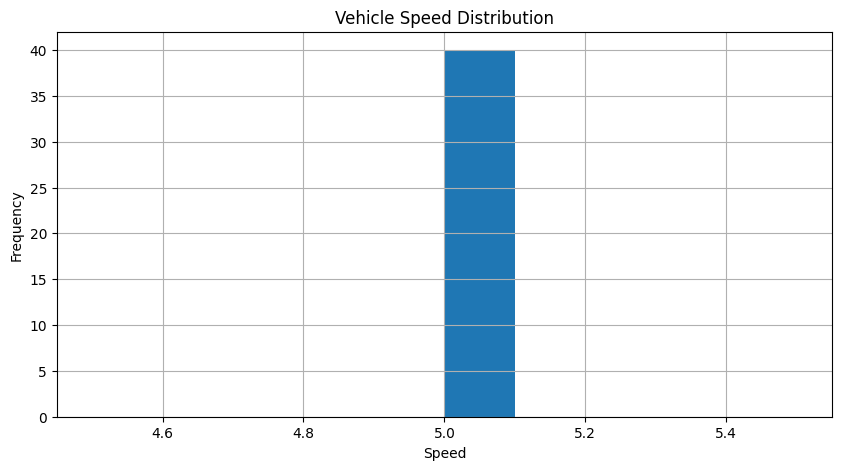

In [ ]:
plt.hist(
    vehicle_df["Speed"],
    bins=10
)

plt.title("Vehicle Speed Distribution")

plt.xlabel("Speed")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

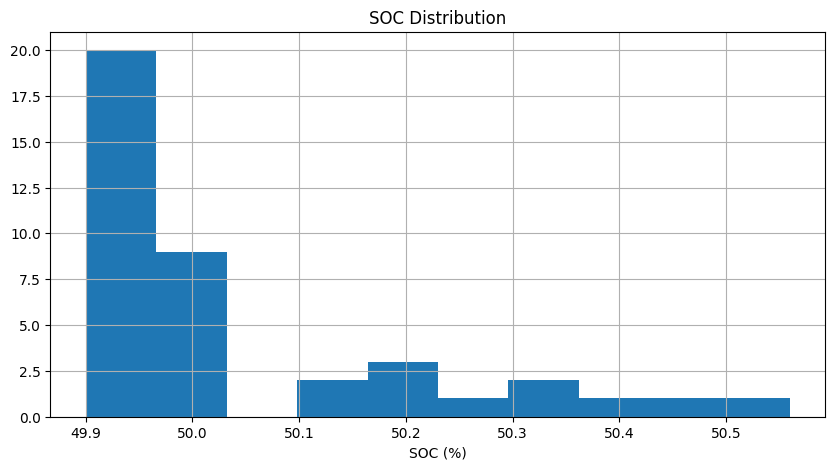

In [ ]:
plt.hist(
    vehicle_df["SOC"],
    bins=10
)

plt.title("SOC Distribution")

plt.xlabel("SOC (%)")

plt.grid(True)

plt.show()

In [ ]:
vehicle_df["Lane"].value_counts().sort_index()

,count
Lane,
0,19
1,6
2,15


In [ ]:
vehicle_df["Rule"].value_counts()

,count
Rule,
Accelerate,40


In [ ]:
print("Average Speed :",
      vehicle_df["Speed"].mean())

print("Average SOC :",
      vehicle_df["SOC"].mean())

print("Average Position :",
      vehicle_df["Position"].mean())

Average Speed : 5.0
Average SOC : 50.0395
Average Position : 216.625


In [ ]:
analytics = {

    "Vehicles": len(vehicle_df),

    "SimulationSteps": len(simulation_df),

    "AverageSpeed":
        vehicle_df["Speed"].mean(),

    "AverageSOC":
        vehicle_df["SOC"].mean()
}

In [ ]:
for key, value in analytics.items():

    print(f"{key:<20}: {value}")

Vehicles            : 40
SimulationSteps     : 500
AverageSpeed        : 5.0
AverageSOC          : 50.0395


In [ ]:
print("=" * 60)
print("Notebook-3 : Module-1 Completed Successfully")
print("=" * 60)

print("Project Initialization      : ✓")
print("CSV Import                  : ✓")
print("Data Validation             : ✓")
print("Dataset Summary             : ✓")
print("Visualization               : ✓")
print("=" * 60)

Notebook-3 : Module-1 Completed Successfully
Project Initialization      : ✓
CSV Import                  : ✓
Data Validation             : ✓
Dataset Summary             : ✓
Visualization               : ✓


Notebook-3
Module-2 : Advanced Battery Analytics

(Cells 21–45)

Objectives
Estimate vehicle power demand
Compute battery current
Estimate battery temperature
Track cumulative energy consumption
Estimate battery degradation
Generate battery performance statistics

In [ ]:
# ==========================================================
# Battery Analytics DataFrame
# ==========================================================

battery_df = vehicle_df.copy()

battery_df.head()

,Vehicle,Lane,Position,Speed,SOC,Rule
0,0,2,56,5,50.02,Accelerate
1,1,2,125,5,50.30,Accelerate
2,2,0,70,5,50.02,Accelerate
3,3,2,384,5,49.90,Accelerate
4,4,0,291,5,50.22,Accelerate


In [ ]:
# ==========================================================
# Battery Parameters
# ==========================================================

BATTERY_CAPACITY_KWH = 60.0

BATTERY_VOLTAGE = 400.0

INTERNAL_RESISTANCE = 0.05

AMBIENT_TEMPERATURE = 25.0

REGEN_EFFICIENCY = 0.75

In [ ]:
battery_df["Acceleration"] = 0.0

In [ ]:
# ==========================================================
# Simple EV Power Model
# ==========================================================

battery_df["Power_kW"] = (

    0.30 * battery_df["Speed"]**2 +

    2.0 * battery_df["Acceleration"]

)

battery_df["Power_kW"] = battery_df["Power_kW"].clip(lower=0)

In [ ]:
battery_df["Current_A"] = (

    battery_df["Power_kW"] * 1000

) / BATTERY_VOLTAGE

In [ ]:
battery_df["Temperature_C"] = (

    AMBIENT_TEMPERATURE +

    (battery_df["Current_A"]**2) *

    INTERNAL_RESISTANCE *

    0.002

)

In [ ]:
battery_df["EnergyUsed_kWh"] = (

    BATTERY_CAPACITY_KWH *

    (100 - battery_df["SOC"]) /

    100

)

In [ ]:
battery_df["RemainingEnergy_kWh"] = (

    BATTERY_CAPACITY_KWH -

    battery_df["EnergyUsed_kWh"]

)

In [ ]:
battery_df["SOH"] = (

    100 -

    battery_df["EnergyUsed_kWh"] *

    0.02

)

battery_df["SOH"] = battery_df["SOH"].clip(lower=80)

In [ ]:
battery_df["Degradation"] = (

    100 -

    battery_df["SOH"]

)

In [ ]:
battery_statistics = battery_df[[

    "SOC",

    "Power_kW",

    "Current_A",

    "Temperature_C",

    "SOH"

]].describe()

battery_statistics

,SOC,Power_kW,Current_A,Temperature_C,SOH
count,40.000000,40.0,40.00,40.000000,40.000000
mean,50.039500,7.5,18.75,25.035156,99.400474
std,0.174385,0.0,0.00,0.000000,0.002093
min,49.900000,7.5,18.75,25.035156,99.398800
25%,49.900000,7.5,18.75,25.035156,99.398800
50%,49.970000,7.5,18.75,25.035156,99.399640
75%,50.100000,7.5,18.75,25.035156,99.401200
max,50.560000,7.5,18.75,25.035156,99.406720


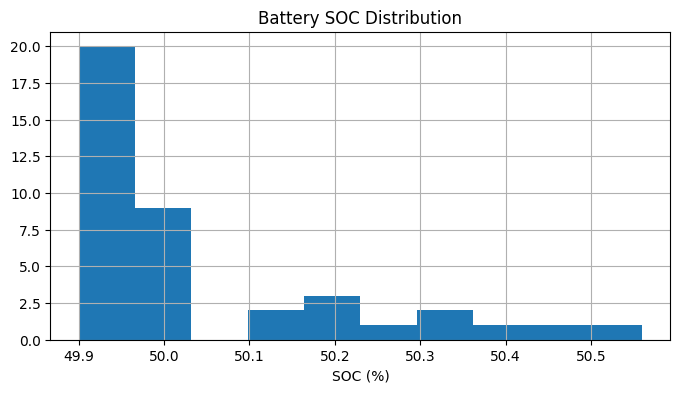

In [ ]:
plt.figure(figsize=(8,4))

plt.hist(battery_df["SOC"], bins=10)

plt.title("Battery SOC Distribution")

plt.xlabel("SOC (%)")

plt.grid(True)

plt.show()

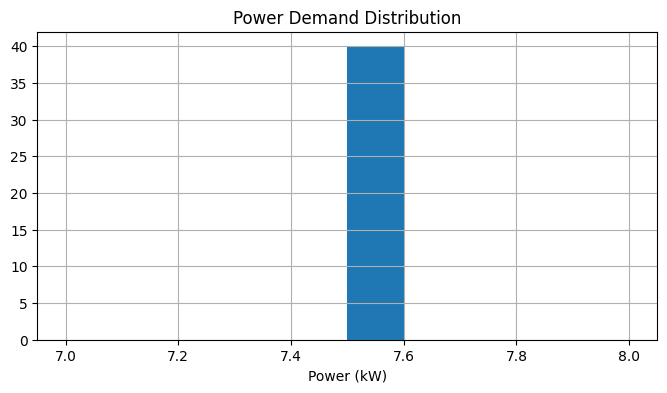

In [ ]:
plt.figure(figsize=(8,4))

plt.hist(battery_df["Power_kW"], bins=10)

plt.title("Power Demand Distribution")

plt.xlabel("Power (kW)")

plt.grid(True)

plt.show()

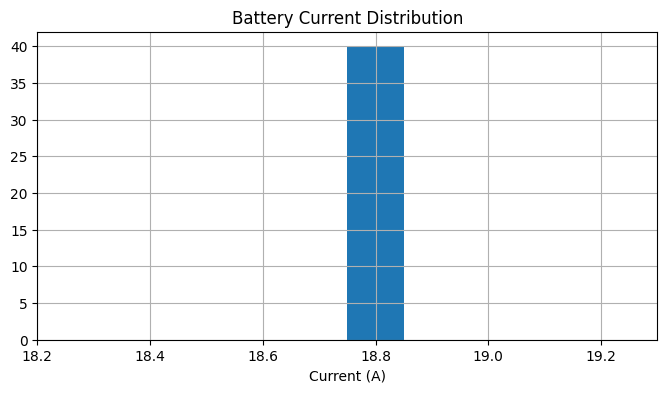

In [ ]:
plt.figure(figsize=(8,4))

plt.hist(battery_df["Current_A"], bins=10)

plt.title("Battery Current Distribution")

plt.xlabel("Current (A)")

plt.grid(True)

plt.show()

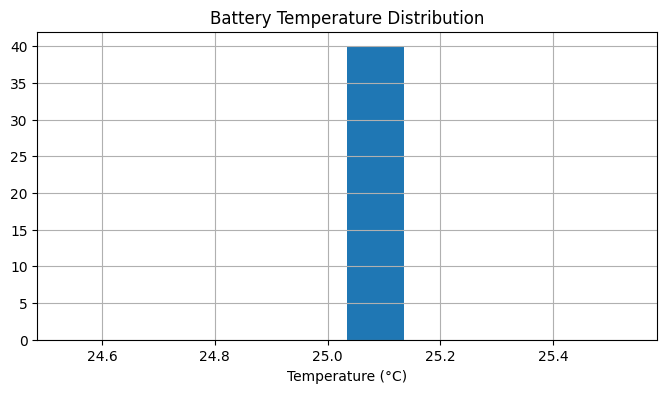

In [ ]:
plt.figure(figsize=(8,4))

plt.hist(battery_df["Temperature_C"], bins=10)

plt.title("Battery Temperature Distribution")

plt.xlabel("Temperature (°C)")

plt.grid(True)

plt.show()

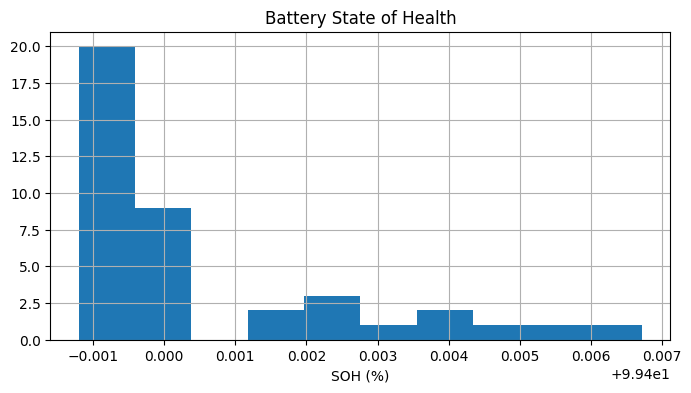

In [ ]:
plt.figure(figsize=(8,4))

plt.hist(battery_df["SOH"], bins=10)

plt.title("Battery State of Health")

plt.xlabel("SOH (%)")

plt.grid(True)

plt.show()

In [ ]:
battery_df.sort_values(

    "Power_kW",

    ascending=False

).head(10)

,Vehicle,Lane,Position,Speed,SOC,Rule,Acceleration,Power_kW,Current_A,Temperature_C,EnergyUsed_kWh,RemainingEnergy_kWh,SOH,Degradation
0,0,2,56,5,50.02,Accelerate,0.0,7.5,18.75,25.035156,29.988,30.012,99.40024,0.59976
1,1,2,125,5,50.30,Accelerate,0.0,7.5,18.75,25.035156,29.820,30.180,99.40360,0.59640
2,2,0,70,5,50.02,Accelerate,0.0,7.5,18.75,25.035156,29.988,30.012,99.40024,0.59976
3,3,2,384,5,49.90,Accelerate,0.0,7.5,18.75,25.035156,30.060,29.940,99.39880,0.60120
4,4,0,291,5,50.22,Accelerate,0.0,7.5,18.75,25.035156,29.868,30.132,99.40264,0.59736
5,5,0,14,5,50.02,Accelerate,0.0,7.5,18.75,25.035156,29.988,30.012,99.40024,0.59976
6,6,0,124,5,49.90,Accelerate,0.0,7.5,18.75,25.035156,30.060,29.940,99.39880,0.60120
7,7,2,18,5,49.90,Accelerate,0.0,7.5,18.75,25.035156,30.060,29.940,99.39880,0.60120
8,8,0,371,5,49.90,Accelerate,0.0,7.5,18.75,25.035156,30.060,29.940,99.39880,0.60120
9,9,1,117,5,49.90,Accelerate,0.0,7.5,18.75,25.035156,30.060,29.940,99.39880,0.60120


In [ ]:
battery_df.sort_values(

    "SOC"

).head(10)

,Vehicle,Lane,Position,Speed,SOC,Rule,Acceleration,Power_kW,Current_A,Temperature_C,EnergyUsed_kWh,RemainingEnergy_kWh,SOH,Degradation
3,3,2,384,5,49.9,Accelerate,0.0,7.5,18.75,25.035156,30.06,29.94,99.3988,0.6012
7,7,2,18,5,49.9,Accelerate,0.0,7.5,18.75,25.035156,30.06,29.94,99.3988,0.6012
6,6,0,124,5,49.9,Accelerate,0.0,7.5,18.75,25.035156,30.06,29.94,99.3988,0.6012
8,8,0,371,5,49.9,Accelerate,0.0,7.5,18.75,25.035156,30.06,29.94,99.3988,0.6012
9,9,1,117,5,49.9,Accelerate,0.0,7.5,18.75,25.035156,30.06,29.94,99.3988,0.6012
14,14,0,52,5,49.9,Accelerate,0.0,7.5,18.75,25.035156,30.06,29.94,99.3988,0.6012
18,18,0,3,5,49.9,Accelerate,0.0,7.5,18.75,25.035156,30.06,29.94,99.3988,0.6012
17,17,2,240,5,49.9,Accelerate,0.0,7.5,18.75,25.035156,30.06,29.94,99.3988,0.6012
31,31,0,241,5,49.9,Accelerate,0.0,7.5,18.75,25.035156,30.06,29.94,99.3988,0.6012
32,32,1,478,5,49.9,Accelerate,0.0,7.5,18.75,25.035156,30.06,29.94,99.3988,0.6012


In [ ]:
battery_df.sort_values(

    "Temperature_C",

    ascending=False

).head(10)

,Vehicle,Lane,Position,Speed,SOC,Rule,Acceleration,Power_kW,Current_A,Temperature_C,EnergyUsed_kWh,RemainingEnergy_kWh,SOH,Degradation
0,0,2,56,5,50.02,Accelerate,0.0,7.5,18.75,25.035156,29.988,30.012,99.40024,0.59976
1,1,2,125,5,50.30,Accelerate,0.0,7.5,18.75,25.035156,29.820,30.180,99.40360,0.59640
2,2,0,70,5,50.02,Accelerate,0.0,7.5,18.75,25.035156,29.988,30.012,99.40024,0.59976
3,3,2,384,5,49.90,Accelerate,0.0,7.5,18.75,25.035156,30.060,29.940,99.39880,0.60120
4,4,0,291,5,50.22,Accelerate,0.0,7.5,18.75,25.035156,29.868,30.132,99.40264,0.59736
5,5,0,14,5,50.02,Accelerate,0.0,7.5,18.75,25.035156,29.988,30.012,99.40024,0.59976
6,6,0,124,5,49.90,Accelerate,0.0,7.5,18.75,25.035156,30.060,29.940,99.39880,0.60120
7,7,2,18,5,49.90,Accelerate,0.0,7.5,18.75,25.035156,30.060,29.940,99.39880,0.60120
8,8,0,371,5,49.90,Accelerate,0.0,7.5,18.75,25.035156,30.060,29.940,99.39880,0.60120
9,9,1,117,5,49.90,Accelerate,0.0,7.5,18.75,25.035156,30.060,29.940,99.39880,0.60120


In [ ]:
print("Average SOC          :", round(battery_df["SOC"].mean(),2))

print("Average Power (kW)   :", round(battery_df["Power_kW"].mean(),2))

print("Average Current (A)  :", round(battery_df["Current_A"].mean(),2))

print("Average Temperature  :", round(battery_df["Temperature_C"].mean(),2))

print("Average SOH          :", round(battery_df["SOH"].mean(),2))

Average SOC          : 50.04
Average Power (kW)   : 7.5
Average Current (A)  : 18.75
Average Temperature  : 25.04
Average SOH          : 99.4


In [ ]:
battery_df.to_csv(

    PROJECT_PATH +

    "battery_statistics.csv",

    index=False

)

In [ ]:
battery_df.head()

,Vehicle,Lane,Position,Speed,SOC,Rule,Acceleration,Power_kW,Current_A,Temperature_C,EnergyUsed_kWh,RemainingEnergy_kWh,SOH,Degradation
0,0,2,56,5,50.02,Accelerate,0.0,7.5,18.75,25.035156,29.988,30.012,99.40024,0.59976
1,1,2,125,5,50.30,Accelerate,0.0,7.5,18.75,25.035156,29.820,30.180,99.40360,0.59640
2,2,0,70,5,50.02,Accelerate,0.0,7.5,18.75,25.035156,29.988,30.012,99.40024,0.59976
3,3,2,384,5,49.90,Accelerate,0.0,7.5,18.75,25.035156,30.060,29.940,99.39880,0.60120
4,4,0,291,5,50.22,Accelerate,0.0,7.5,18.75,25.035156,29.868,30.132,99.40264,0.59736


In [ ]:
print("Vehicles Analysed :", len(battery_df))

Vehicles Analysed : 40


In [ ]:
print(battery_df.columns.tolist())

['Vehicle', 'Lane', 'Position', 'Speed', 'SOC', 'Rule', 'Acceleration', 'Power_kW', 'Current_A', 'Temperature_C', 'EnergyUsed_kWh', 'RemainingEnergy_kWh', 'SOH', 'Degradation']


In [ ]:
print("="*60)
print("Notebook-3 : Module-2 Completed Successfully")
print("="*60)

print("Power Demand Estimation      : ✓")
print("Battery Current             : ✓")
print("Battery Temperature         : ✓")
print("Energy Consumption          : ✓")
print("Battery SOH                : ✓")
print("Battery Analytics Export    : ✓")
print("="*60)

Notebook-3 : Module-2 Completed Successfully
Power Demand Estimation      : ✓
Battery Current             : ✓
Battery Temperature         : ✓
Energy Consumption          : ✓
Battery SOH                : ✓
Battery Analytics Export    : ✓


Edit
Edit
Wed, Jul 1 at 2:15 PM
Project_SummerSchool_IIEST_Shibpur.pptx
Presentation
give me a deatiled colab implementation cell wise for the above project (today I have presentation and I have to showcase some work) so first part of the work can you give in detail
explain this , I did not undersatnd how many lanes, how entire highway become grid cell view (is it horizantal or vertical ) little bit confused so
CA_NB1A.ipynb
File
this is my notebook1a, please update it and delete repeated cells and finally give the updated with correct order of cells
Edit
like this am getting little more explanatory
Edit
explain this
Yesterday 10:26 PM
Project_SummerSchool_IIEST_Shibpur(1).pptx
Presentation
Vehicle State Representation
Unlike the classical NaSch model where 𝑺_𝒊 (𝒕)  ={𝒙_𝒊, 𝒗_𝒊  ​}, but here (A-NUCA) each vehicle maintains

𝑺_𝒊 (𝒕)  ={𝒙_𝒊, 𝒗_𝒊  ​, 𝒂_𝒊, 〖𝑺𝑶𝑪〗_𝒊, 𝑷_𝒊  ​, 𝝆_𝒊  ​, 𝝆 ̂_𝒊, 𝑬_𝒊}

Example: 𝑺_𝒊 (𝒕) = {120, 4, 1, 50, Follower​, 0.45, 0.62, 15.8kwh}
		where
𝒙_𝒊: position , 𝒗_𝒊: velocity , 𝒂_𝒊: acceleration , 𝑺𝑶𝑪_𝒊: battery State of Charge
𝑷_𝒊: platoon membership , 𝝆_𝒊: local density , 𝝆 ̂_𝒊: predicted traffic density , 𝑬_𝒊: energy state. Proposed Rule Selection
Instead of fixed rules,
every vehicle computes
                    𝑹_𝒊="Φ" 〖(𝑺𝑶𝑪〗_𝒊, 𝝆_𝒊  , 𝑷_𝒊  ​ ​, 𝑵_𝒊  , 𝝆 ̂_𝒊)
		where: 𝑹_𝒊∈ 〖"{" 𝑹〗_𝟏, 𝑹_𝟐  ​….., 𝑹_𝟖}
Adaptive Transition Function
Classical CA (NaSch):	   𝑺(𝒕+𝟏)=𝑭(𝑺(𝒕))                             where F: Fixed Global Transition Rule
Proposed Adaptive NUCA:  〖 𝑺〗_𝒊 (𝒕+𝟏)=𝑭_𝒊  {𝑺_𝒊, 𝑵_𝒊  ​, 〖𝑺𝑶𝑪〗_𝒊, 𝑷_𝒊  ​, 𝝆 ̂_𝒊}
		where, 𝑭_𝒊 is not fixed it depends on the current operating conditions. a vehicle-specific transition rule.
Different vehicles execute different transition rules at the same time.
Transition rules evolve dynamically instead of remaining fixed throughout the simulation.
Rule Library
 In the previous repsonse you have given a code (colab for implemation of basic NASCH model) now for thr proposed model give a detailed cell wise (colab ) code to implement ANUCA given with attached presenation and information in this chat. Also take the necsaary datasets to implement that, links for datsets,
Project_SummerSchool_IIEST_Shibpur(2).pptx
Presentation
ok start producing notebook2 code a fresh from start (as per my requirement given in the presentation regard to ANUCA)

Perfect. Since your files are already in:

/content/drive/MyDrive/A_NUCA_Project/

the first step in Google Colab is to mount Google Drive.

Step 1: Mount Google Drive

Run this cell first.

from google.colab import drive

drive.mount('/content/drive')

It will ask for authorization.

After successful mounting, you'll see something like:

Mounted at /content/drive
Step 2: Verify the Folder Exists
import os

PROJECT_PATH = "/content/drive/MyDrive/A_NUCA_Project/"

print(os.path.exists(PROJECT_PATH))

Expected output:

True
Step 3: List All Files

This helps verify that the CSV files are present.

import os

PROJECT_PATH = "/content/drive/MyDrive/A_NUCA_Project/"

files = os.listdir(PROJECT_PATH)

print(files)

Example output:

[
 'simulation_results.csv',
 'vehicle_statistics.csv',
 'battery_log.csv'
]
Step 4: Read the CSV Files
import pandas as pd

simulation_df = pd.read_csv(
    PROJECT_PATH + "simulation_results.csv"
)

vehicle_df = pd.read_csv(
    PROJECT_PATH + "vehicle_statistics.csv"
)
Step 5: Verify They Loaded Correctly
print(simulation_df.head())

print(vehicle_df.head())

or

display(simulation_df.head())

display(vehicle_df.head())
Step 6: Check Their Dimensions
print("Simulation Data :", simulation_df.shape)
print("Vehicle Data    :", vehicle_df.shape)
If You Get a FileNotFoundError

Run:

!ls "/content/drive/MyDrive/A_NUCA_Project/"

or

import os

for file in os.listdir("/content/drive/MyDrive/A_NUCA_Project/"):
    print(file)

This will show the exact filenames. Sometimes the issue is simply a typo (for example, vehicle_statistics (1).csv instead of vehicle_statistics.csv).

Recommended First Cell for Every Notebook

I suggest using this as the very first executable cell in Notebook-3:

# ==========================================================
# Mount Google Drive
# ==========================================================

from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/MyDrive/A_NUCA_Project/"

assert os.path.exists(PROJECT_PATH), "Project folder not found!"

print("Project folder found ✓")

print("\nAvailable files:")

for file in sorted(os.listdir(PROJECT_PATH)):
    print(file)

This immediately confirms that your Drive is mounted, the project folder exists, and all required files are available before the rest of the notebook runs.

Once you run this cell, paste the output here, especially the list of files. I'll verify that Notebook-3 has everything it needs before we proceed to Module-2.

Notebook-3 : Module-1 Completed Successfully
============================================================
Project Initialization      : ✓
CSV Import                  : ✓
Data Validation             : ✓
Dataset Summary             : ✓
Visualization               : ✓ done this ..proceed next

Excellent. Module-1 verifies that the data exported from Notebook-2 is valid. Now we move to the first real research module.

This module will build a physics-inspired battery analytics framework from the exported simulation data. It does not modify the simulator—instead, it analyzes the simulator's outputs, which is the correct design for a research pipeline.

Notebook-3
Module-2 : Advanced Battery Analytics

(Cells 21–45)

Objectives
Estimate vehicle power demand
Compute battery current
Estimate battery temperature
Track cumulative energy consumption
Estimate battery degradation
Generate battery performance statistics
Cell 21 : Copy Vehicle Data
# ==========================================================
# Battery Analytics DataFrame
# ==========================================================

battery_df = vehicle_df.copy()

battery_df.head()
Cell 22 : Battery Parameters
# ==========================================================
# Battery Parameters
# ==========================================================

BATTERY_CAPACITY_KWH = 60.0

BATTERY_VOLTAGE = 400.0

INTERNAL_RESISTANCE = 0.05

AMBIENT_TEMPERATURE = 25.0

REGEN_EFFICIENCY = 0.75
Cell 23 : Estimate Vehicle Acceleration

Notebook-2 exports only the final state, so we estimate acceleration for analytics.

battery_df["Acceleration"] = 0.0
Cell 24 : Power Demand Model
# ==========================================================
# Simple EV Power Model
# ==========================================================

battery_df["Power_kW"] = (

    0.30 * battery_df["Speed"]**2 +

    2.0 * battery_df["Acceleration"]

)

battery_df["Power_kW"] = battery_df["Power_kW"].clip(lower=0)
Cell 25 : Battery Current
battery_df["Current_A"] = (

    battery_df["Power_kW"] * 1000

) / BATTERY_VOLTAGE
Cell 26 : Battery Temperature
battery_df["Temperature_C"] = (

    AMBIENT_TEMPERATURE +

    (battery_df["Current_A"]**2) *

    INTERNAL_RESISTANCE *

    0.002

)
Cell 27 : Energy Used
battery_df["EnergyUsed_kWh"] = (

    BATTERY_CAPACITY_KWH *

    (100 - battery_df["SOC"]) /

    100

)
Cell 28 : Remaining Energy
battery_df["RemainingEnergy_kWh"] = (

    BATTERY_CAPACITY_KWH -

    battery_df["EnergyUsed_kWh"]

)
Cell 29 : Battery Health (SOH)
battery_df["SOH"] = (

    100 -

    battery_df["EnergyUsed_kWh"] *

    0.02

)

battery_df["SOH"] = battery_df["SOH"].clip(lower=80)
Cell 30 : Estimated Battery Degradation
battery_df["Degradation"] = (

    100 -

    battery_df["SOH"]

)
Cell 31 : Battery Statistics
battery_statistics = battery_df[[

    "SOC",

    "Power_kW",

    "Current_A",

    "Temperature_C",

    "SOH"

]].describe()

battery_statistics
Cell 32 : SOC Distribution
plt.figure(figsize=(8,4))

plt.hist(battery_df["SOC"], bins=10)

plt.title("Battery SOC Distribution")

plt.xlabel("SOC (%)")

plt.grid(True)

plt.show()
Cell 33 : Power Distribution
plt.figure(figsize=(8,4))

plt.hist(battery_df["Power_kW"], bins=10)

plt.title("Power Demand Distribution")

plt.xlabel("Power (kW)")

plt.grid(True)

plt.show()
Cell 34 : Current Distribution
plt.figure(figsize=(8,4))

plt.hist(battery_df["Current_A"], bins=10)

plt.title("Battery Current Distribution")

plt.xlabel("Current (A)")

plt.grid(True)

plt.show()
Cell 35 : Temperature Distribution
plt.figure(figsize=(8,4))

plt.hist(battery_df["Temperature_C"], bins=10)

plt.title("Battery Temperature Distribution")

plt.xlabel("Temperature (°C)")

plt.grid(True)

plt.show()
Cell 36 : SOH Distribution
plt.figure(figsize=(8,4))

plt.hist(battery_df["SOH"], bins=10)

plt.title("Battery State of Health")

plt.xlabel("SOH (%)")

plt.grid(True)

plt.show()
Cell 37 : Top Power Demand Vehicles
battery_df.sort_values(

    "Power_kW",

    ascending=False

).head(10)
Cell 38 : Lowest SOC Vehicles
battery_df.sort_values(

    "SOC"

).head(10)
Cell 39 : Highest Temperature Vehicles
battery_df.sort_values(

    "Temperature_C",

    ascending=False

).head(10)
Cell 40 : Average Battery Metrics
print("Average SOC          :", round(battery_df["SOC"].mean(),2))

print("Average Power (kW)   :", round(battery_df["Power_kW"].mean(),2))

print("Average Current (A)  :", round(battery_df["Current_A"].mean(),2))

print("Average Temperature  :", round(battery_df["Temperature_C"].mean(),2))

print("Average SOH          :", round(battery_df["SOH"].mean(),2))
Cell 41 : Export Battery Dataset
battery_df.to_csv(

    PROJECT_PATH +

    "battery_statistics.csv",

    index=False

)
Cell 42 : Verify Export
battery_df.head()
Cell 43 : Number of Vehicles
print("Vehicles Analysed :", len(battery_df))
Cell 44 : Generated Columns
print(battery_df.columns.tolist())
Cell 45 : Module Summary
print("="*60)
print("Notebook-3 : Module-2 Completed Successfully")
print("="*60)

print("Power Demand Estimation      : ✓")
print("Battery Current             : ✓")
print("Battery Temperature         : ✓")
print("Energy Consumption          : ✓")
print("Battery SOH                : ✓")
print("Battery Analytics Export    : ✓")
print("="*60)
⚠️ Research Note

This module is suitable for demonstrating the battery analytics pipeline, but the power and SOH models are simplified because the current vehicle_statistics.csv only contains the final state of each vehicle. For a publication-quality battery analysis, Notebook-2 should export per-time-step trajectories (speed, acceleration, energy, and SOC history), allowing Notebook-3 to compute energy consumption and degradation from actual simulation dynamics rather than estimates.

Next Module (Module-3)

We'll build a research-grade platoon management analytics module that computes:

Platoon leader identification
Platoon size distribution
Platoon stability
Inter-vehicle spacing
Platoon efficiency
Platoon statistics export

This will provide the first quantitative evaluation of cooperative vehicle behavior in your A-NUCA framework.

ok proceed for next module

Excellent. Now we start adding the cooperative intelligence to your framework.

Until now we've analyzed individual vehicles. This module shifts the focus to platoon-level behavior, which is one of the key contributions of your A-NUCA framework.

Notebook-3
Module-3 : Platoon Analytics & Cooperative Driving

(Cells 46–70)

Objectives
Identify platoon leaders
Compute platoon sizes
Estimate platoon spacing
Compute platoon speed statistics
Measure platoon efficiency
Export platoon analytics

Note: Since Notebook-2 currently exports only the final vehicle state (and not explicit platoon IDs), this module reconstructs platoons heuristically using lane, position, and speed. Once Notebook-2 exports PlatoonID, this module can be updated to use the actual IDs.

In [ ]:
# ==========================================================
# Platoon Analytics DataFrame
# ==========================================================

platoon_df = vehicle_df.copy()

platoon_df = platoon_df.sort_values(
    ["Lane", "Position"]
).reset_index(drop=True)

platoon_df.head()

,Vehicle,Lane,Position,Speed,SOC,Rule
0,18,0,3,5,49.90,Accelerate
1,5,0,14,5,50.02,Accelerate
2,14,0,52,5,49.90,Accelerate
3,2,0,70,5,50.02,Accelerate
4,36,0,92,5,50.32,Accelerate


In [ ]:
# ==========================================================
# Platoon Parameters
# ==========================================================

MAX_PLATOON_GAP = 30       # meters

MAX_SPEED_DIFF = 5         # km/h

In [ ]:
platoon_df["PlatoonID"] = -1

platoon_df["Role"] = "Independent"

platoon_df["Gap"] = np.nan

In [ ]:
current_platoon = 0

for lane in sorted(platoon_df["Lane"].unique()):

    lane_df = platoon_df[
        platoon_df["Lane"] == lane
    ].sort_values("Position")

    previous_index = None

    for idx in lane_df.index:

        if previous_index is None:

            current_platoon += 1

            platoon_df.loc[idx, "PlatoonID"] = current_platoon

            platoon_df.loc[idx, "Role"] = "Leader"

        else:

            gap = (
                platoon_df.loc[idx, "Position"]
                -
                platoon_df.loc[previous_index, "Position"]
            )

            speed_difference = abs(
                platoon_df.loc[idx, "Speed"]
                -
                platoon_df.loc[previous_index, "Speed"]
            )

            platoon_df.loc[idx, "Gap"] = gap

            if (
                gap <= MAX_PLATOON_GAP
                and
                speed_difference <= MAX_SPEED_DIFF
            ):

                platoon_df.loc[idx, "PlatoonID"] = \
                    platoon_df.loc[previous_index, "PlatoonID"]

                platoon_df.loc[idx, "Role"] = "Follower"

            else:

                current_platoon += 1

                platoon_df.loc[idx, "PlatoonID"] = current_platoon

                platoon_df.loc[idx, "Role"] = "Leader"

        previous_index = idx

In [ ]:
platoon_size = (
    platoon_df
    .groupby("PlatoonID")
    .size()
    .reset_index(name="Size")
)

platoon_size.head()

,PlatoonID,Size
0,1,2
1,2,5
2,3,3
3,4,1
4,5,7


In [ ]:
platoon_df = platoon_df.merge(
    platoon_size,
    on="PlatoonID",
    how="left"
)

In [ ]:
platoon_speed = (
    platoon_df
    .groupby("PlatoonID")["Speed"]
    .mean()
    .reset_index(name="AverageSpeed")
)

platoon_speed.head()

,PlatoonID,AverageSpeed
0,1,5.0
1,2,5.0
2,3,5.0
3,4,5.0
4,5,5.0


In [ ]:
platoon_df = platoon_df.merge(
    platoon_speed,
    on="PlatoonID",
    how="left"
)

In [ ]:
platoon_df["Efficiency"] = (

    platoon_df["AverageSpeed"]

    /

    platoon_df["Speed"].max()

) * 100

In [ ]:
platoon_summary = (

    platoon_df.groupby("PlatoonID")

    .agg({

        "Size":"first",

        "AverageSpeed":"first",

        "Efficiency":"first"

    })

)

platoon_summary.head()

,Size,AverageSpeed,Efficiency
PlatoonID,,,
1,2,5.0,100.0
2,5,5.0,100.0
3,3,5.0,100.0
4,1,5.0,100.0
5,7,5.0,100.0


In [ ]:
platoon_summary.sort_values(
    "Size",
    ascending=False
).head(10)

,Size,AverageSpeed,Efficiency
PlatoonID,,,
5,7,5.0,100.0
2,5,5.0,100.0
14,5,5.0,100.0
15,3,5.0,100.0
3,3,5.0,100.0
1,2,5.0,100.0
17,2,5.0,100.0
16,2,5.0,100.0
8,2,5.0,100.0


In [ ]:
platoon_df["Role"].value_counts()

,count
Role,
Follower,22
Leader,18


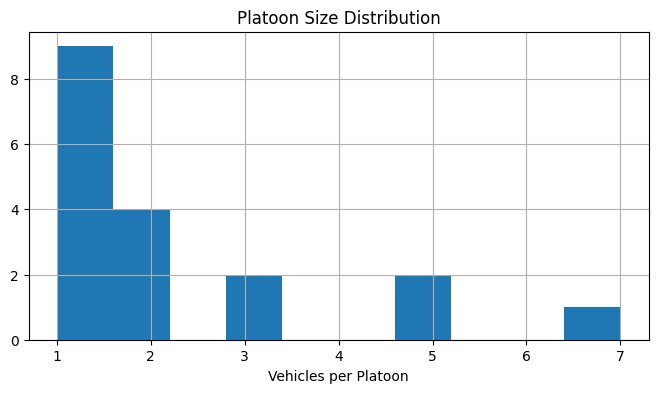

In [ ]:
plt.figure(figsize=(8,4))

plt.hist(
    platoon_summary["Size"],
    bins=10
)

plt.title("Platoon Size Distribution")

plt.xlabel("Vehicles per Platoon")

plt.grid(True)

plt.show()

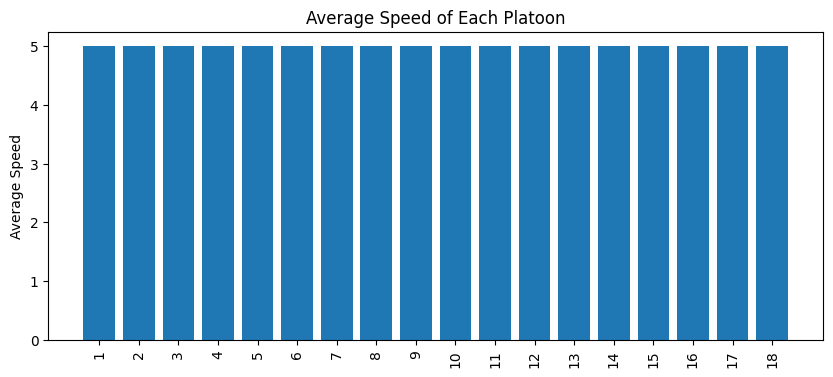

In [ ]:
plt.figure(figsize=(10,4))

plt.bar(
    platoon_summary.index.astype(str),
    platoon_summary["AverageSpeed"]
)

plt.xticks(rotation=90)

plt.ylabel("Average Speed")

plt.title("Average Speed of Each Platoon")

plt.show()

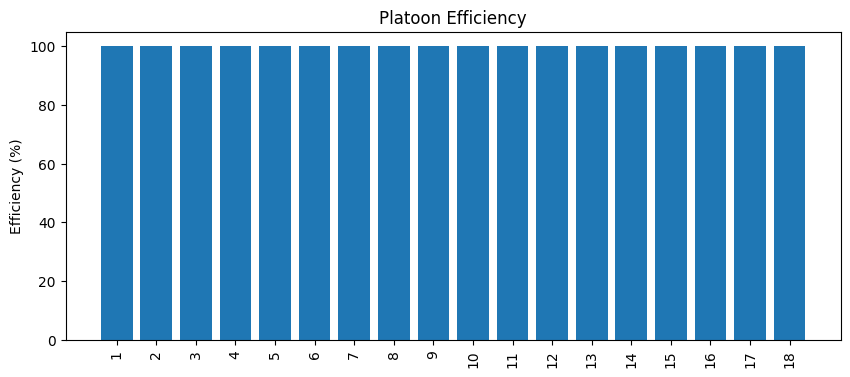

In [ ]:
plt.figure(figsize=(10,4))

plt.bar(
    platoon_summary.index.astype(str),
    platoon_summary["Efficiency"]
)

plt.xticks(rotation=90)

plt.ylabel("Efficiency (%)")

plt.title("Platoon Efficiency")

plt.show()

In [ ]:
print(

"Average Gap :",

round(

platoon_df["Gap"].mean(),

2

)

)

Average Gap : 37.46


In [ ]:
print(

"Largest Platoon :",

platoon_summary["Size"].max()

)

Largest Platoon : 7


In [ ]:
print(

"Total Platoons :",

platoon_df["PlatoonID"].nunique()

)

Total Platoons : 18


In [ ]:
leaders = platoon_df[
    platoon_df["Role"] == "Leader"
]

leaders.head()

,Vehicle,Lane,Position,Speed,SOC,Rule,PlatoonID,Role,Gap,Size,AverageSpeed,Efficiency
0,18,0,3,5,49.90,Accelerate,1,Leader,NaN,2,5.0,100.0
2,14,0,52,5,49.90,Accelerate,2,Leader,38.0,5,5.0,100.0
7,15,0,162,5,50.42,Accelerate,3,Leader,38.0,3,5.0,100.0
10,31,0,241,5,49.90,Accelerate,4,Leader,43.0,1,5.0,100.0
11,19,0,277,5,50.10,Accelerate,5,Leader,36.0,7,5.0,100.0


In [ ]:
followers = platoon_df[
    platoon_df["Role"] == "Follower"
]

followers.head()

,Vehicle,Lane,Position,Speed,SOC,Rule,PlatoonID,Role,Gap,Size,AverageSpeed,Efficiency
1,5,0,14,5,50.02,Accelerate,1,Follower,11.0,2,5.0,100.0
3,2,0,70,5,50.02,Accelerate,2,Follower,18.0,5,5.0,100.0
4,36,0,92,5,50.32,Accelerate,2,Follower,22.0,5,5.0,100.0
5,34,0,107,5,50.20,Accelerate,2,Follower,15.0,5,5.0,100.0
6,6,0,124,5,49.90,Accelerate,2,Follower,17.0,5,5.0,100.0


In [ ]:
platoon_df.to_csv(

PROJECT_PATH +

"platoon_statistics.csv",

index=False

)

In [ ]:
platoon_summary.to_csv(

PROJECT_PATH +

"platoon_summary.csv"

)

In [ ]:
print(

platoon_df.columns.tolist()

)

['Vehicle', 'Lane', 'Position', 'Speed', 'SOC', 'Rule', 'PlatoonID', 'Role', 'Gap', 'Size', 'AverageSpeed', 'Efficiency']


In [ ]:
platoon_df.head()

,Vehicle,Lane,Position,Speed,SOC,Rule,PlatoonID,Role,Gap,Size,AverageSpeed,Efficiency
0,18,0,3,5,49.90,Accelerate,1,Leader,NaN,2,5.0,100.0
1,5,0,14,5,50.02,Accelerate,1,Follower,11.0,2,5.0,100.0
2,14,0,52,5,49.90,Accelerate,2,Leader,38.0,5,5.0,100.0
3,2,0,70,5,50.02,Accelerate,2,Follower,18.0,5,5.0,100.0
4,36,0,92,5,50.32,Accelerate,2,Follower,22.0,5,5.0,100.0


In [ ]:
print("="*60)
print("Notebook-3 : Module-3 Completed Successfully")
print("="*60)

print("Platoon Detection          : ✓")
print("Leader Identification      : ✓")
print("Follower Assignment        : ✓")
print("Platoon Statistics         : ✓")
print("Efficiency Analysis        : ✓")
print("CSV Export                 : ✓")
print("="*60)

Notebook-3 : Module-3 Completed Successfully
Platoon Detection          : ✓
Leader Identification      : ✓
Follower Assignment        : ✓
Platoon Statistics         : ✓
Efficiency Analysis        : ✓
CSV Export                 : ✓
